In [1]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

PROJECT_ROOT = Path("/root/autodl-tmp")

from config import LEARNING_RATE, MAX_EPOCHS, WEIGHT_DECAY, XLSR_DROPOUT
from config import DANN_LAMBDA_CLASS, DANN_LAMBDA_DOMAIN
from model_DANN import AD_XLSR_Model_DANN, compute_alpha
from dataset import create_dataloaders
from visualization import plot_training_curves, plot_dataset_comparison

2025-12-24 10:34:35 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


In [2]:
SOURCE_DATASET = "Pitt"
TARGET_DATASET = "Lu"

SOURCE_WEIGHT = 0.5  # Weight for source domain validation accuracy
TARGET_WEIGHT = 0.5  # Weight for target domain validation accuracy

MIN_SOURCE_ACC = 0.67  # Minimum required source domain validation accuracy (0.0-1.0)
MIN_TARGET_ACC = 0.65  # Minimum required target domain validation accuracy (0.0-1.0)

DANN_LAMBDA_DOMAIN = 1  

DOMAIN_WARMUP_EPOCHS = 0    # First n epochs train only source domain classifier， 30 is the best
DOMAIN_ANNEAL_RATIO = 0.5   # Next 25% epochs linearly increase lambda to maximum

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [3]:
# ============= Feature Extraction Configuration =============
# Set to True to extract features using finetuned XLSR
EXTRACT_FEATURES = True

# Feature extraction settings
USE_FINETUNED_XLSR = True  # True: use finetuned XLSR, False: use original
FINETUNED_MODEL_PATH = f"/root/autodl-tmp/data/{SOURCE_DATASET}-finetuned-xlsr.pth"
RAW_AUDIO_DIR = Path(f"/root/autodl-tmp/data/raw/{SOURCE_DATASET}")

# Output configuration
if USE_FINETUNED_XLSR:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_finetuned_features"
    CSV_SUFFIX = "finetuned"
else:
    FEATURE_DIR_NAME = f"{SOURCE_DATASET}_xlsr_features"
    CSV_SUFFIX = ""

In [4]:
# ============= Execute Feature Extraction =============
if EXTRACT_FEATURES:
    print("Starting feature extraction...\n")

    from extract_XLSR_feature import extract_features_from_csv
    from model import SSLModel
    import csv

    # Step 1: Initialize SSLModel with optional finetuned weights
    print("Initializing XLSR model...")
    ssl_model = SSLModel(
        device=device,
        freeze_xlsr=True,
        finetuned_model_path=FINETUNED_MODEL_PATH if USE_FINETUNED_XLSR else None
    )
    print()

    # Step 2: Use existing CSV files to extract features
    data_dir = Path("/root/autodl-tmp/data/processed")

    # CSV文件已经存在，直接使用
    train_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
    val_csv_path = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"

    # 特征保存到新目录
    xlsr_features_dir = data_dir / FEATURE_DIR_NAME

    print(f"Using existing CSV files:")
    print(f"  Train: {train_csv_path.name}")
    print(f"  Val: {val_csv_path.name}")
    print(f"Extracting features to: {xlsr_features_dir}\n")

    # Step 3: Extract features using the existing function
    print(f"Processing train set...")
    extract_features_from_csv(
        csv_path=train_csv_path,
        split_name=f"{SOURCE_DATASET}-train",
        raw_audio_dir=RAW_AUDIO_DIR,
        xlsr_features_dir=xlsr_features_dir,
        device=device,
        ssl_model=ssl_model,  # Pass the initialized model
        freeze_xlsr=True
    )

    print(f"\nProcessing validation set...")
    extract_features_from_csv(
        csv_path=val_csv_path,
        split_name=f"{SOURCE_DATASET}-val",
        raw_audio_dir=RAW_AUDIO_DIR,
        xlsr_features_dir=xlsr_features_dir,
        device=device,
        ssl_model=ssl_model,  # Pass the same model
        freeze_xlsr=True
    )

    # Step 4: 更新CSV文件中的xlsr_path列
    print(f"\nUpdating CSV files to point to new features...")
    for csv_file in [train_csv_path, val_csv_path]:
        # 读取CSV
        with open(csv_file, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        # 更新xlsr_path列
        for row in rows:
            session_id = row['session_id']
            row['xlsr_path'] = f"{FEATURE_DIR_NAME}/{session_id}.xlsr.pt"

        # 写回CSV
        with open(csv_file, 'w', encoding='utf-8', newline='') as f:
            fieldnames = ['session_id', 'xlsr_path', 'ad']
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

        print(f"  Updated: {csv_file.name}")

    print(f"\n{'='*60}")
    print(f"Feature extraction complete!")
    print(f"Features saved to: {xlsr_features_dir}")
    print(f"CSV files updated to use new features")
    print(f"{'='*60}\n")

    # Clean up GPU memory
    torch.cuda.empty_cache()

else:
    print("Feature extraction skipped (EXTRACT_FEATURES=False)\n")

Starting feature extraction...

Initializing XLSR model...
XLSR: Loading base model structure


/root/miniconda3/envs/xlsr_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Loading finetuned weights from /root/autodl-tmp/data/Pitt-finetuned-xlsr.pth
XLSR: ✓ Loaded finetuned model from epoch 12
XLSR: ✓ Best validation accuracy: 69.37%

Using existing CSV files:
  Train: Pitt-xlsr-train.csv
  Val: Pitt-xlsr-val.csv
Extracting features to: /root/autodl-tmp/data/processed/Pitt_xlsr_finetuned_features

Processing train set...

============= Extracting XLSR features for Pitt-train =============
440 Audio Files


Extracting Pitt-train:   0%|          | 0/440 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 440
Errors: 0
Total: 440

Processing validation set...

============= Extracting XLSR features for Pitt-val =============
111 Audio Files


Extracting Pitt-val:   0%|          | 0/111 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 111
Errors: 0
Total: 111

Updating CSV files to point to new features...
  Updated: Pitt-xlsr-train.csv
  Updated: Pitt-xlsr-val.csv

Feature extraction complete!
Features saved to: /root/autodl-tmp/data/processed/Pitt_xlsr_finetuned_features
CSV files updated to use new features



In [5]:
data_dir = PROJECT_ROOT / "data" / "processed"

SOURCE_TRAIN_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-train.csv"
TARGET_TRAIN_CSV = data_dir / f"{TARGET_DATASET}-xlsr-train.csv"
TARGET_VAL_CSV = data_dir / f"{TARGET_DATASET}-xlsr-val.csv"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"FINETUNED_DANN_{SOURCE_DATASET}_to_{TARGET_DATASET}_xlsr"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1 Load Data

In [6]:
source_train_loader = create_dataloaders(data_csv=SOURCE_TRAIN_CSV, xlsr=True)

SOURCE_VAL_CSV = data_dir / f"{SOURCE_DATASET}-xlsr-val.csv"
source_val_loader = create_dataloaders(data_csv=SOURCE_VAL_CSV, xlsr=True)

target_train_loader = create_dataloaders(data_csv=TARGET_TRAIN_CSV, xlsr=True)
target_val_loader = create_dataloaders(data_csv=TARGET_VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 111 samples
Control: 49, Dementia: 62


Loading completed: 58 samples
Control: 28, Dementia: 30


Loading completed: 16 samples
Control: 8, Dementia: 8




## 2 Model Architecture

In [7]:
test_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT)

## 3 Define Training Functions


In [8]:
def compute_domain_lambda(epoch, total_epochs, base_lambda=DANN_LAMBDA_DOMAIN,
                         warmup_epochs=DOMAIN_WARMUP_EPOCHS, anneal_ratio=DOMAIN_ANNEAL_RATIO):
    """Schedule domain loss weight based on epoch.
    - Warmup phase: First warmup_epochs epochs, lambda=0, train only source domain classifier
    - Then linearly increase to base_lambda over anneal_ratio proportion of epochs
    - Remaining phase: Maintain base_lambda
    """
    warmup_epochs = min(warmup_epochs, total_epochs)
    anneal_epochs = int(total_epochs * anneal_ratio)
    if epoch <= warmup_epochs:
        return 0.0
    if anneal_epochs <= 0:
        return base_lambda
    progress = min(1.0, max(0, epoch - warmup_epochs) / max(1, anneal_epochs))
    return base_lambda * progress


In [9]:
def train_one_epoch_dann(model, source_loader, target_loader, optimizer, device, epoch, total_epochs, 
                         lambda_class=DANN_LAMBDA_CLASS, lambda_domain=DANN_LAMBDA_DOMAIN):
    """Train one epoch with DANN
    
    Args:
        lambda_class: Classification loss weight (default: 1.0)
        lambda_domain: Domain adversarial loss weight for current epoch
    """
    model.train()
    
    total_class_loss = 0
    total_domain_loss = 0
    correct = 0
    total = 0
    domain_correct = 0
    domain_total = 0
    
    target_iter = iter(target_loader)
    len_source = len(source_loader)
    total_steps = total_epochs * len_source
    lambda_active = lambda_domain > 0
    
    pbar = tqdm(enumerate(source_loader), total=len_source, desc=f"Epoch {epoch}", leave=False)
    
    for i, source_batch in pbar:
        # Compute alpha (gradient reversal strength)
        current_step = (epoch - 1) * len_source + i
        alpha = compute_alpha(current_step, total_steps)
        
        # ===== Process source domain data =====
        source_features, source_labels, source_masks = source_batch
        source_features = source_features.to(device)
        source_labels = source_labels.to(device)
        source_masks = source_masks.to(device)
        
        if lambda_active:
            class_output, domain_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=True
            )
        else:
            class_output = model(
                source_features,
                mask=source_masks,
                alpha=alpha,
                return_features=False
            )
            domain_output = None
        
        # Source domain label = 0
        source_domain_labels = torch.zeros(source_labels.size(0), dtype=torch.long).to(device)
        
        # Compute classification loss
        loss_class = F.cross_entropy(class_output, source_labels)
        
        if lambda_active:
            loss_domain_source = F.cross_entropy(domain_output, source_domain_labels)
            try:
                target_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_batch = next(target_iter)
            target_features, _, target_masks = target_batch  # Do not use target domain labels!
            target_features = target_features.to(device)
            target_masks = target_masks.to(device)
            _, domain_output_target = model(
                target_features,
                mask=target_masks,
                alpha=alpha,
                return_features=True
            )
            target_domain_labels = torch.ones(target_features.size(0), dtype=torch.long).to(device)
            loss_domain_target = F.cross_entropy(domain_output_target, target_domain_labels)
        else:
            loss_domain_source = torch.zeros(1, device=device)
            loss_domain_target = torch.zeros(1, device=device)
            target_domain_labels = None
            domain_output_target = None
        
        total_batch_loss = (lambda_class * loss_class +
                           lambda_domain * (loss_domain_source + loss_domain_target))
        
        optimizer.zero_grad()
        total_batch_loss.backward()
        optimizer.step()
        
        total_class_loss += loss_class.item()
        total_domain_loss += (loss_domain_source.item() + loss_domain_target.item())
        
        predictions = torch.argmax(class_output, dim=1)
        correct += (predictions == source_labels).sum().item()
        total += source_labels.size(0)
        
        if lambda_active:
            domain_pred_source = torch.argmax(domain_output, dim=1)
            domain_pred_target = torch.argmax(domain_output_target, dim=1)
            domain_correct += (domain_pred_source == source_domain_labels).sum().item()
            domain_correct += (domain_pred_target == target_domain_labels).sum().item()
            domain_total += source_domain_labels.size(0) + target_domain_labels.size(0)
        
        pbar.set_postfix({
            'α': f'{alpha:.2f}',
            'λ_dom': f'{lambda_domain:.3f}',
            'cls': f'{loss_class.item():.3f}',
            'dom': f'{(loss_domain_source.item() + loss_domain_target.item()):.3f}',
            'acc': f'{correct/total:.3f}'
        })
    
    avg_class_loss = total_class_loss / len_source
    avg_domain_loss = total_domain_loss / len_source
    train_acc = correct / total
    domain_acc = (domain_correct / domain_total) if domain_total > 0 else 0.0
    
    return avg_class_loss, avg_domain_loss, train_acc, domain_acc


In [10]:
def validate_dann(model, val_loader, device):
    """Validate DANN model"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    control_correct, control_total = 0, 0
    dementia_correct, dementia_total = 0, 0
    tp, fp, fn = 0, 0, 0
    
    with torch.no_grad():
        for features, labels, masks in val_loader:
            features = features.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
            
            logits = model(features, mask=masks, return_features=False)
            
            loss = F.cross_entropy(logits, labels)
            predictions = torch.argmax(logits, dim=1)
            
            total_loss += loss.item()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            for pred, label in zip(predictions, labels):
                if label == 0:
                    control_total += 1
                    if pred == label:
                        control_correct += 1
                else:
                    dementia_total += 1
                    if pred == label:
                        dementia_correct += 1
                
                if pred == 1 and label == 1:
                    tp += 1
                elif pred == 1 and label == 0:
                    fp += 1
                elif pred == 0 and label == 1:
                    fn += 1
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    control_acc = control_correct / control_total if control_total > 0 else 0
    dementia_acc = dementia_correct / dementia_total if dementia_total > 0 else 0
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return avg_loss, accuracy, control_acc, dementia_acc, f1_score

In [11]:
def train_dann(seed, source_train_loader, target_train_loader, source_val_loader, target_val_loader, 
               output_dir, device, source_weight=0.5, target_weight=0.5, 
               min_source_acc=0.0, min_target_acc=0.0):
    """Complete DANN training pipeline
    
    Args:
        min_source_acc: Minimum required source domain validation accuracy for best model selection
        min_target_acc: Minimum required target domain validation accuracy for best model selection
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    
    seed_dir = Path(output_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    
    model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    history = {
        'epochs': [],
        'train_class_losses': [],
        'train_domain_losses': [],
        'train_accs': [],
        'source_val_accs': [],
        'target_val_accs': [],
        'avg_val_accs': [],
        'val_losses': [],
        'val_accs': [],
        'domain_accs': [],
        'lambda_domains': []
    }
    
    best_avg_acc = 0
    best_metrics = {}
    best_avg_acc_relaxed = 0  # Track best model without threshold constraints
    best_metrics_relaxed = {}
    
    print(f"\n{'='*60}")
    print(f"Training Seed {seed}")
    print(f"Model Selection: Average Accuracy (Source {source_weight:.3f}, Target {target_weight:.3f})")
    print(f"Accuracy Thresholds: Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f}")
    print(f"{'='*60}")
    
    for epoch in range(1, MAX_EPOCHS + 1):
        current_lambda_domain = compute_domain_lambda(epoch, MAX_EPOCHS)
        class_loss, domain_loss, train_acc, domain_acc = train_one_epoch_dann(
            model, source_train_loader, target_train_loader, optimizer, device, epoch, MAX_EPOCHS,
            lambda_class=DANN_LAMBDA_CLASS,
            lambda_domain=current_lambda_domain
        )
        
        source_val_loss, source_val_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
            model, source_val_loader, device
        )
        
        target_val_loss, target_val_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
            model, target_val_loader, device
        )
        
        avg_val_acc = source_weight * source_val_acc + target_weight * target_val_acc
        
        history['epochs'].append(epoch)
        history['train_class_losses'].append(class_loss)
        history['train_domain_losses'].append(domain_loss)
        history['train_accs'].append(train_acc)
        history['source_val_accs'].append(source_val_acc)
        history['target_val_accs'].append(target_val_acc)
        history['avg_val_accs'].append(avg_val_acc)
        history['val_losses'].append(target_val_loss)
        history['val_accs'].append(target_val_acc)
        history['domain_accs'].append(domain_acc)
        history['lambda_domains'].append(current_lambda_domain)
        
        print(f"Epoch {epoch:3d} | Train: {train_acc:.3f} | Source Val: {source_val_acc:.3f} | "
              f"Target Val: {target_val_acc:.3f} | Avg: {avg_val_acc:.3f} | Domain: {domain_acc:.3f} | "
              f"λ_dom: {current_lambda_domain:.3f}")
        
        # Always track the best model without threshold constraints
        if avg_val_acc > best_avg_acc_relaxed:
            best_avg_acc_relaxed = avg_val_acc
            best_metrics_relaxed = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            torch.save(model.state_dict(), seed_dir / 'best_dann_relaxed.pth')
        
        # Check if current model meets all criteria: better avg_val_acc AND meets minimum accuracy thresholds
        if (avg_val_acc > best_avg_acc and 
            source_val_acc >= min_source_acc and 
            target_val_acc >= min_target_acc):
            best_avg_acc = avg_val_acc
            best_metrics = {
                'avg_val_acc': avg_val_acc,
                'source_val_acc': source_val_acc,
                'target_val_acc': target_val_acc,
                'source_val_loss': source_val_loss,
                'target_val_loss': target_val_loss,
                'source_control_acc': source_control_acc,
                'source_dementia_acc': source_dementia_acc,
                'target_control_acc': target_control_acc,
                'target_dementia_acc': target_dementia_acc,
                'source_f1': source_f1,
                'target_f1': target_f1,
                'epoch': epoch
            }
            torch.save(model.state_dict(), seed_dir / 'best_dann.pth')
    
    if best_metrics:
        print(f"\nBest Results (Epoch {best_metrics['epoch']}) - Meets All Thresholds:")
        print(f"  Avg Acc: {best_metrics['avg_val_acc']*100:.2f}%")
        print(f"  Source ({SOURCE_DATASET}): {best_metrics['source_val_acc']*100:.2f}% | F1: {best_metrics['source_f1']:.4f}")
        print(f"  Target ({TARGET_DATASET}): {best_metrics['target_val_acc']*100:.2f}% | F1: {best_metrics['target_f1']:.4f}")
    else:
        print(f"\nNo epoch met the minimum accuracy thresholds (Source >= {min_source_acc:.2f}, Target >= {min_target_acc:.2f})")
        if best_metrics_relaxed:
            print(f"Using best relaxed model (Epoch {best_metrics_relaxed['epoch']}):")
            print(f"  Avg Acc: {best_metrics_relaxed['avg_val_acc']*100:.2f}%")
            print(f"  Source ({SOURCE_DATASET}): {best_metrics_relaxed['source_val_acc']*100:.2f}% | F1: {best_metrics_relaxed['source_f1']:.4f}")
            print(f"  Target ({TARGET_DATASET}): {best_metrics_relaxed['target_val_acc']*100:.2f}% | F1: {best_metrics_relaxed['target_f1']:.4f}")
            # Copy relaxed model as the best model
            import shutil
            shutil.copy(seed_dir / 'best_dann_relaxed.pth', seed_dir / 'best_dann.pth')
            best_metrics = best_metrics_relaxed
    
    return seed, best_metrics, history

In [12]:
def evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device):
    """Evaluate model performance on both datasets and visualize"""
    print(f"{'='*60}")
    print(f"Evaluating Best Model (Seed {seed})")
    print(f"{'='*60}")
 
    best_model = AD_XLSR_Model_DANN(dropout=XLSR_DROPOUT).to(device)
    best_model.load_state_dict(torch.load(model_path, map_location=device))
    
    source_loss, source_acc, source_control_acc, source_dementia_acc, source_f1 = validate_dann(
        best_model, source_val_loader, device
    )
    target_loss, target_acc, target_control_acc, target_dementia_acc, target_f1 = validate_dann(
        best_model, target_val_loader, device
    )
    
    print(f"{'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
    print(f"{'-'*85}")
    print(f"{f'{SOURCE_DATASET} (source domain)':<25} {source_acc*100:>10.2f}%  {source_f1:>10.4f}  {source_dementia_acc*100:>10.2f}%  {source_control_acc*100:>10.2f}%  {source_loss:>8.4f}")
    print(f"{f'{TARGET_DATASET} (target domain)':<25} {target_acc*100:>10.2f}%  {target_f1:>10.4f}  {target_dementia_acc*100:>10.2f}%  {target_control_acc*100:>10.2f}%  {target_loss:>8.4f}")
    print(f"{'-'*85}")
    
    # Visualize accuracy comparison
    dataset_names = [f'{SOURCE_DATASET} (source)', f'{TARGET_DATASET} (target)']
    accuracies = [source_acc * 100, target_acc * 100]
    
    custom_colors = {
        f'{SOURCE_DATASET} (source)': '#3498db',
        f'{TARGET_DATASET} (target)': '#e74c3c'
    }
    
    plot_dataset_comparison(
        dataset_names=dataset_names,
        accuracies=accuracies,
        title=f'DANN Performance Comparison (Seed {seed})',
        custom_colors=custom_colors
    )
    
    source_metrics = {
        'acc': source_acc, 'f1': source_f1,
        'dementia_acc': source_dementia_acc,
        'control_acc': source_control_acc,
        'loss': source_loss
    }
    target_metrics = {
        'acc': target_acc, 'f1': target_f1,
        'dementia_acc': target_dementia_acc,
        'control_acc': target_control_acc,
        'loss': target_loss
    }
    return source_metrics, target_metrics

## 4 Training with Multiple Seeds


In [13]:
all_results = {
    'seeds': [],
    'metrics': [],
    'histories': [],
    'source_metrics': [],
    'target_metrics': []
}

### Seed 21


Training Seed 21
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.67, Target >= 0.65


Epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.620 | Source Val: 0.577 | Target Val: 0.562 | Avg: 0.570 | Domain: 0.488 | λ_dom: 0.033


Epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.798 | Source Val: 0.604 | Target Val: 0.562 | Avg: 0.583 | Domain: 0.508 | λ_dom: 0.067


...

Epoch  58 | Train: 0.875 | Source Val: 0.676 | Target Val: 0.750 | Avg: 0.713 | Domain: 0.520 | λ_dom: 1.000


Epoch 59:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  59 | Train: 0.925 | Source Val: 0.649 | Target Val: 0.625 | Avg: 0.637 | Domain: 0.525 | λ_dom: 1.000


Epoch 60:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  60 | Train: 0.952 | Source Val: 0.613 | Target Val: 0.562 | Avg: 0.588 | Domain: 0.526 | λ_dom: 1.000

Best Results (Epoch 58) - Meets All Thresholds:
  Avg Acc: 71.28%
  Source (Pitt): 67.57% | F1: 0.7313
  Target (Lu): 75.00% | F1: 0.7500


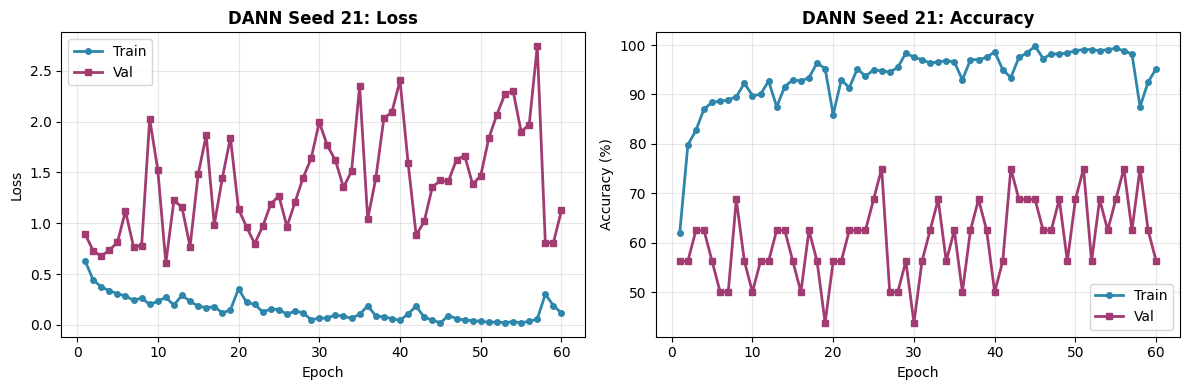

In [14]:
seed, metrics, history = train_dann(
    seed=21,
    source_train_loader=source_train_loader,
    target_train_loader=target_train_loader,
    source_val_loader=source_val_loader,
    target_val_loader=target_val_loader,
    output_dir=MODEL_OUTPUT_DIR,
    device=device,
    source_weight=SOURCE_WEIGHT,
    target_weight=TARGET_WEIGHT,
    min_source_acc=MIN_SOURCE_ACC,
    min_target_acc=MIN_TARGET_ACC
)

all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)

plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_class_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'DANN Seed {seed}'
)

Evaluating Best Model (Seed 21)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           67.57%      0.7313       79.03%       53.06%    0.9970
Lu (target domain)             75.00%      0.7500       75.00%       75.00%    0.8070
-------------------------------------------------------------------------------------


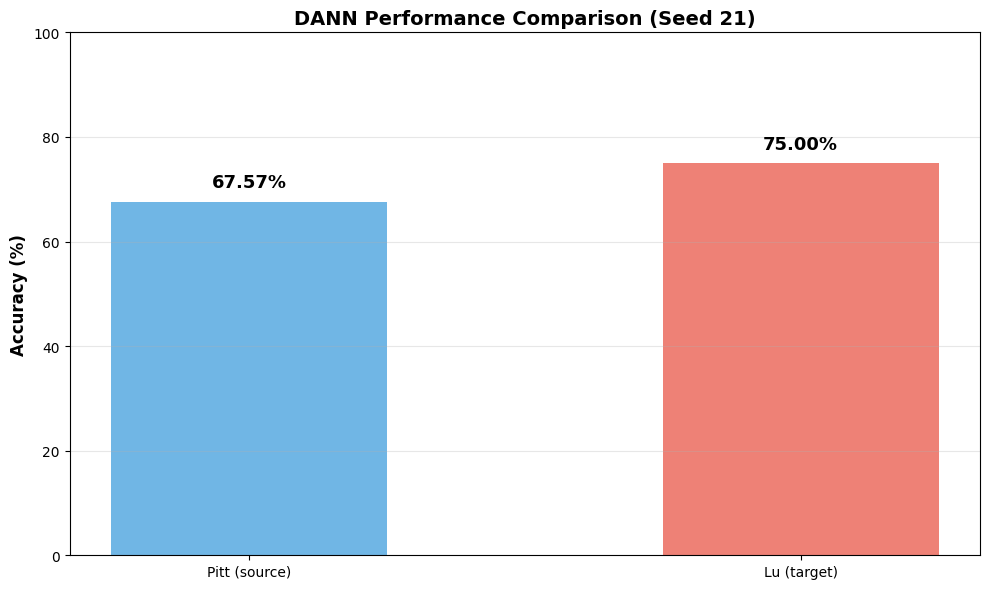

In [15]:
model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(
    seed, source_val_loader, target_val_loader, model_path, device
)

all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 42


Training Seed 42
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.67, Target >= 0.65


Epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.691 | Source Val: 0.586 | Target Val: 0.438 | Avg: 0.512 | Domain: 0.522 | λ_dom: 0.033


Epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.807 | Source Val: 0.640 | Target Val: 0.500 | Avg: 0.570 | Domain: 0.539 | λ_dom: 0.067


...

Epoch  58 | Train: 0.975 | Source Val: 0.613 | Target Val: 0.500 | Avg: 0.556 | Domain: 0.488 | λ_dom: 1.000


Epoch 59:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  59 | Train: 0.982 | Source Val: 0.604 | Target Val: 0.500 | Avg: 0.552 | Domain: 0.489 | λ_dom: 1.000


Epoch 60:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  60 | Train: 0.957 | Source Val: 0.640 | Target Val: 0.500 | Avg: 0.570 | Domain: 0.520 | λ_dom: 1.000

Best Results (Epoch 38) - Meets All Thresholds:
  Avg Acc: 69.96%
  Source (Pitt): 71.17% | F1: 0.7681
  Target (Lu): 68.75% | F1: 0.7059


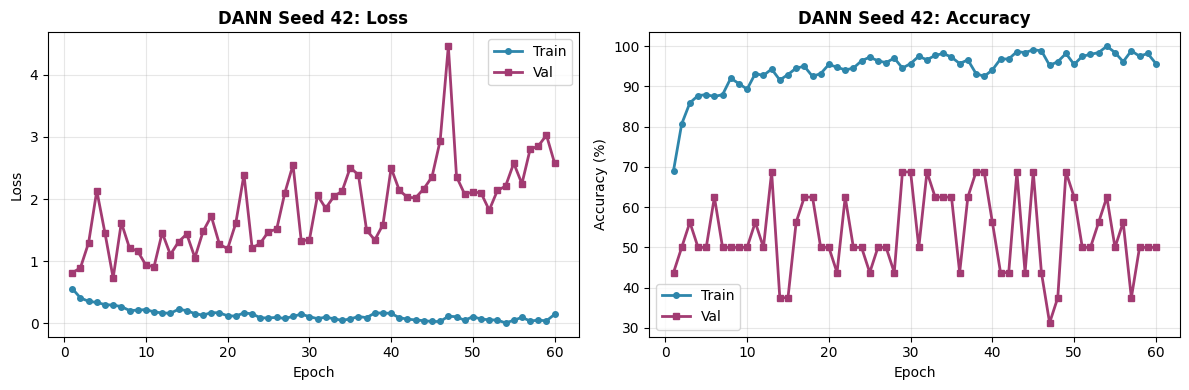

Evaluating Best Model (Seed 42)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           71.17%      0.7681       85.48%       53.06%    1.3622
Lu (target domain)             68.75%      0.7059       75.00%       62.50%    1.3425
-------------------------------------------------------------------------------------


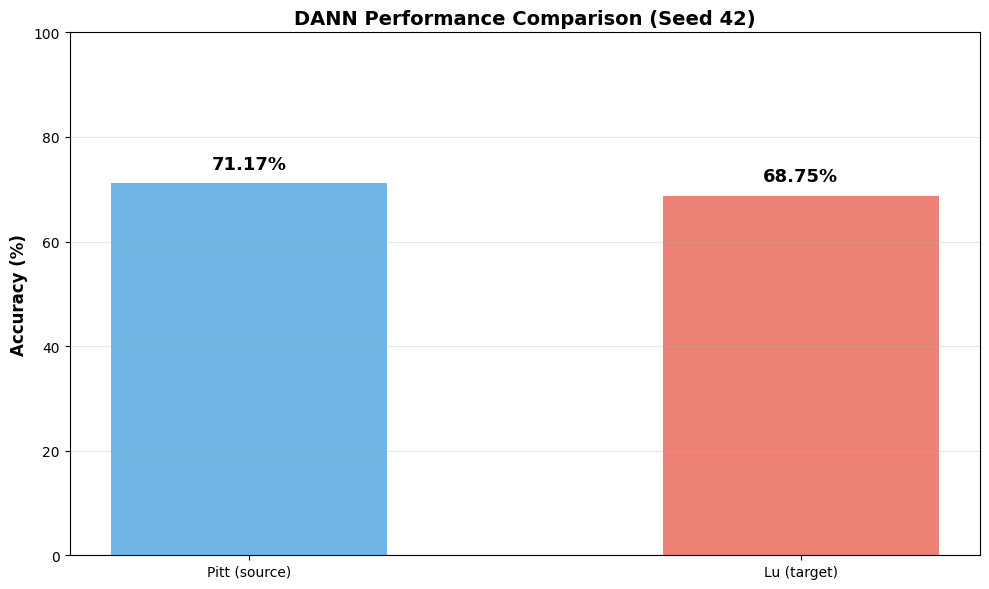

In [16]:
seed, metrics, history = train_dann(42, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 84


Training Seed 84
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.67, Target >= 0.65


Epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.675 | Source Val: 0.568 | Target Val: 0.250 | Avg: 0.409 | Domain: 0.512 | λ_dom: 0.033


Epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.791 | Source Val: 0.595 | Target Val: 0.562 | Avg: 0.579 | Domain: 0.522 | λ_dom: 0.067


...

Epoch  58 | Train: 0.975 | Source Val: 0.658 | Target Val: 0.688 | Avg: 0.673 | Domain: 0.506 | λ_dom: 1.000


Epoch 59:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  59 | Train: 0.977 | Source Val: 0.658 | Target Val: 0.688 | Avg: 0.673 | Domain: 0.468 | λ_dom: 1.000


Epoch 60:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  60 | Train: 0.959 | Source Val: 0.631 | Target Val: 0.500 | Avg: 0.565 | Domain: 0.509 | λ_dom: 1.000

No epoch met the minimum accuracy thresholds (Source >= 0.67, Target >= 0.65)
Using best relaxed model (Epoch 13):
  Avg Acc: 72.61%
  Source (Pitt): 63.96% | F1: 0.6875
  Target (Lu): 81.25% | F1: 0.8235


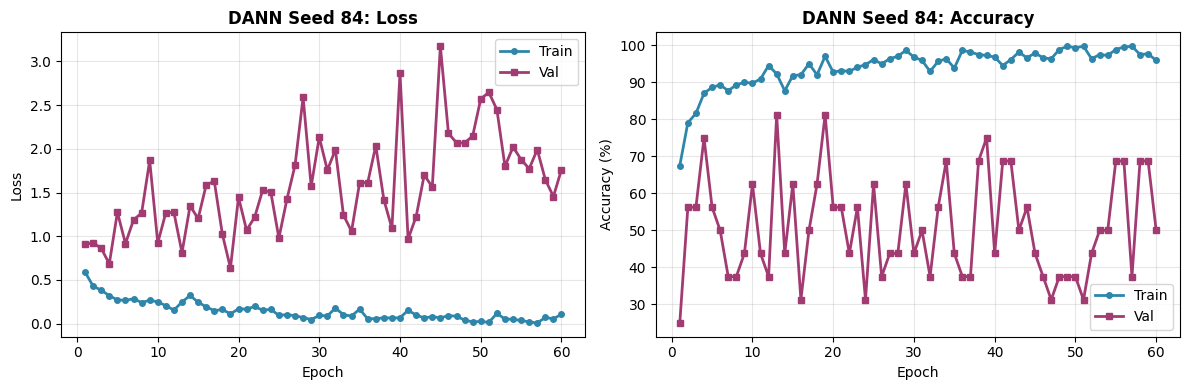

Evaluating Best Model (Seed 84)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           63.96%      0.6875       70.97%       55.10%    1.1340
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    0.8116
-------------------------------------------------------------------------------------


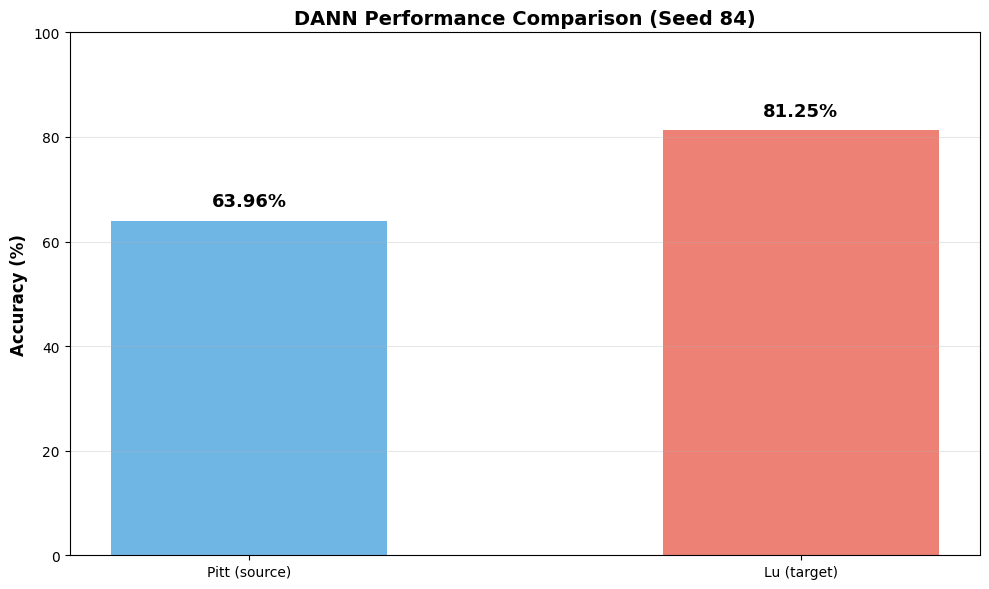

In [17]:
seed, metrics, history = train_dann(84, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 168


Training Seed 168
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.67, Target >= 0.65


Epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.720 | Source Val: 0.568 | Target Val: 0.500 | Avg: 0.534 | Domain: 0.512 | λ_dom: 0.033


Epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.798 | Source Val: 0.586 | Target Val: 0.562 | Avg: 0.574 | Domain: 0.527 | λ_dom: 0.067


...

Epoch  58 | Train: 0.980 | Source Val: 0.667 | Target Val: 0.625 | Avg: 0.646 | Domain: 0.467 | λ_dom: 1.000


Epoch 59:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  59 | Train: 0.991 | Source Val: 0.658 | Target Val: 0.625 | Avg: 0.641 | Domain: 0.520 | λ_dom: 1.000


Epoch 60:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  60 | Train: 0.980 | Source Val: 0.586 | Target Val: 0.375 | Avg: 0.480 | Domain: 0.506 | λ_dom: 1.000

Best Results (Epoch 20) - Meets All Thresholds:
  Avg Acc: 69.06%
  Source (Pitt): 69.37% | F1: 0.7463
  Target (Lu): 68.75% | F1: 0.7059


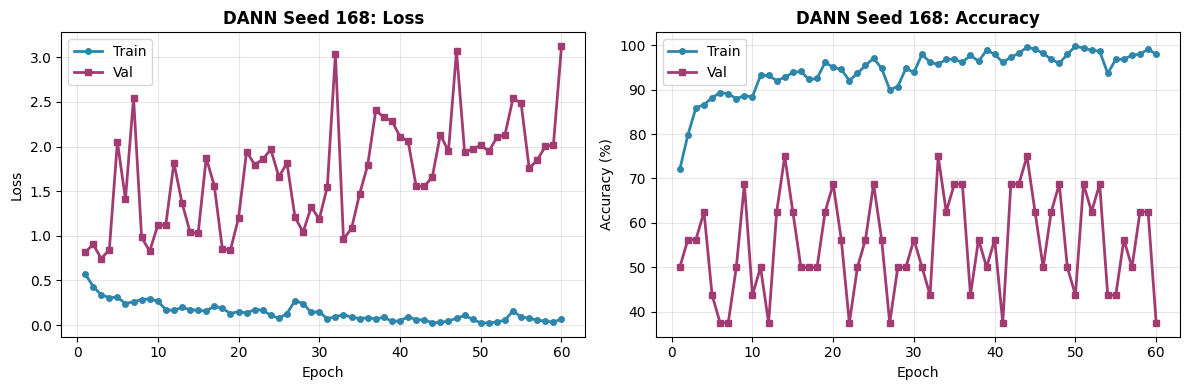

Evaluating Best Model (Seed 168)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           69.37%      0.7463       80.65%       55.10%    1.2152
Lu (target domain)             68.75%      0.7059       75.00%       62.50%    1.1988
-------------------------------------------------------------------------------------


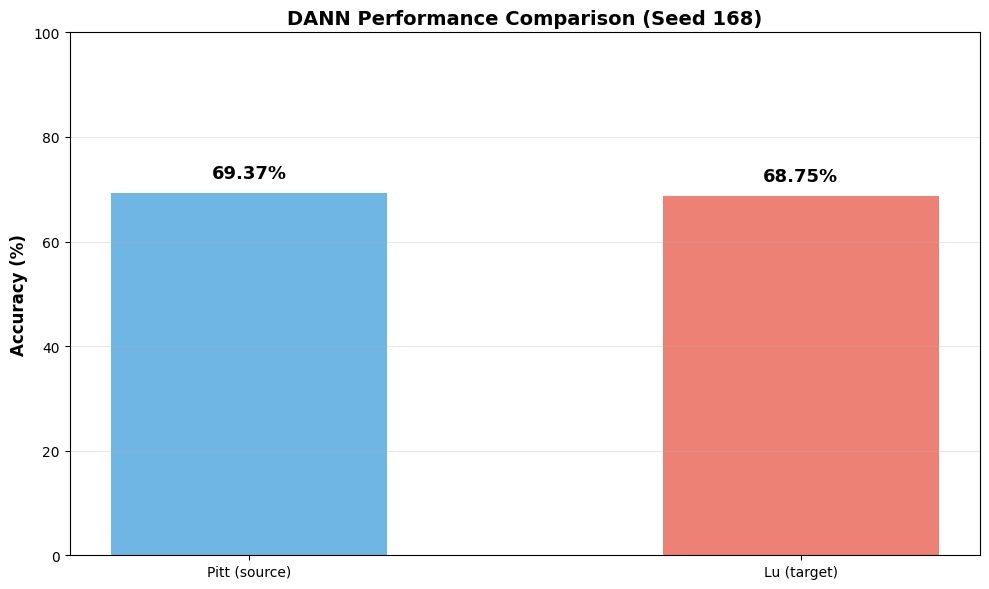

In [18]:
seed, metrics, history = train_dann(168, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


### Seed 336


Training Seed 336
Model Selection: Average Accuracy (Source 0.500, Target 0.500)
Accuracy Thresholds: Source >= 0.67, Target >= 0.65


Epoch 1:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   1 | Train: 0.711 | Source Val: 0.595 | Target Val: 0.375 | Avg: 0.485 | Domain: 0.517 | λ_dom: 0.033


Epoch 2:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch   2 | Train: 0.811 | Source Val: 0.595 | Target Val: 0.500 | Avg: 0.547 | Domain: 0.509 | λ_dom: 0.067


...

Epoch  58 | Train: 0.982 | Source Val: 0.613 | Target Val: 0.438 | Avg: 0.525 | Domain: 0.539 | λ_dom: 1.000


Epoch 59:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  59 | Train: 0.982 | Source Val: 0.613 | Target Val: 0.438 | Avg: 0.525 | Domain: 0.524 | λ_dom: 1.000


Epoch 60:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch  60 | Train: 0.973 | Source Val: 0.604 | Target Val: 0.562 | Avg: 0.583 | Domain: 0.506 | λ_dom: 1.000

No epoch met the minimum accuracy thresholds (Source >= 0.67, Target >= 0.65)
Using best relaxed model (Epoch 12):
  Avg Acc: 72.61%
  Source (Pitt): 63.96% | F1: 0.7403
  Target (Lu): 81.25% | F1: 0.8235


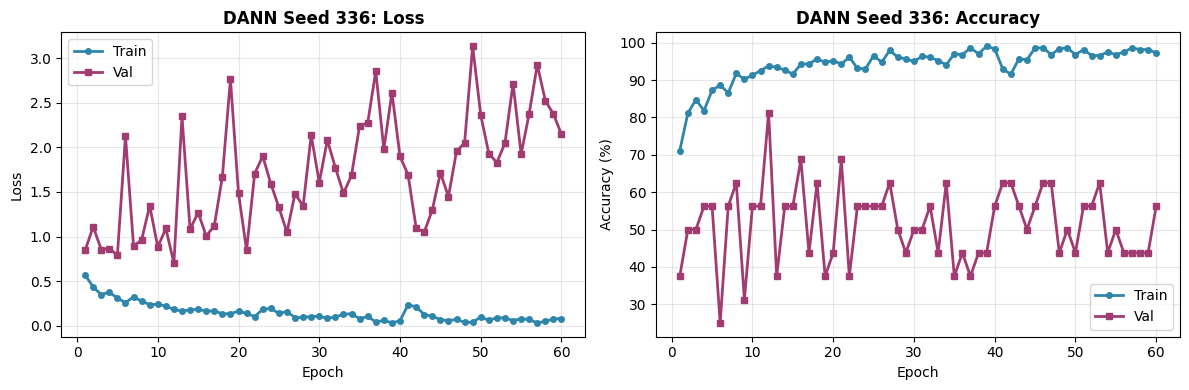

Evaluating Best Model (Seed 336)
Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
-------------------------------------------------------------------------------------
Pitt (source domain)           63.96%      0.7403       91.94%       28.57%    1.1559
Lu (target domain)             81.25%      0.8235       87.50%       75.00%    0.6999
-------------------------------------------------------------------------------------


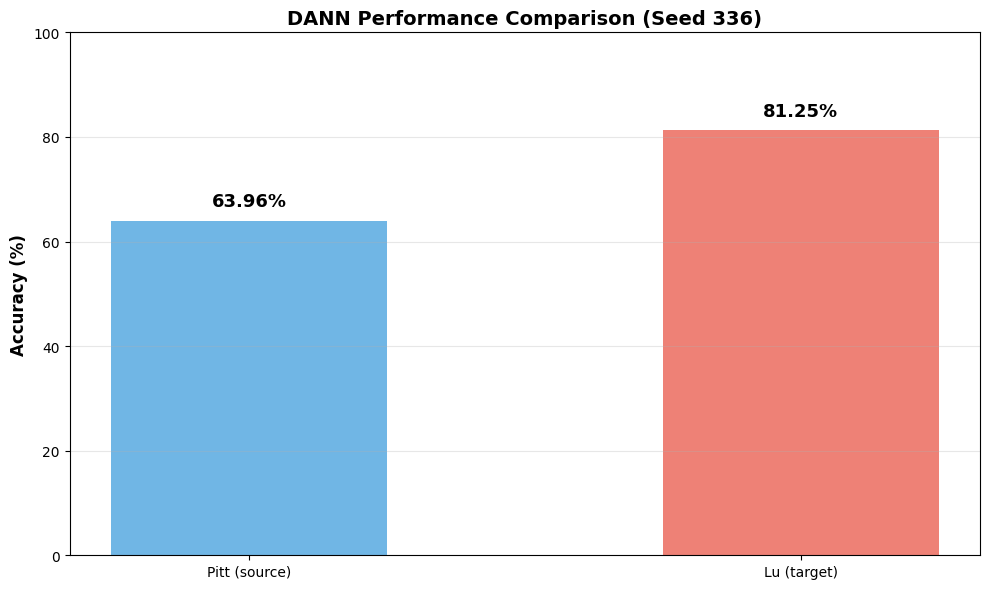

In [19]:
seed, metrics, history = train_dann(336, source_train_loader, target_train_loader, 
                                     source_val_loader, target_val_loader, MODEL_OUTPUT_DIR, device,
                                     source_weight=SOURCE_WEIGHT, target_weight=TARGET_WEIGHT,
                                     min_source_acc=MIN_SOURCE_ACC, min_target_acc=MIN_TARGET_ACC)
all_results['seeds'].append(seed)
all_results['metrics'].append(metrics)
all_results['histories'].append(history)
plot_training_curves(history['epochs'], history['train_class_losses'], history['val_losses'], 
                     history['train_accs'], history['val_accs'], title_prefix=f'DANN Seed {seed}')

model_path = MODEL_OUTPUT_DIR / f"seed_{seed}" / "best_dann.pth"
source_metrics, target_metrics = evaluate_and_visualize(seed, source_val_loader, target_val_loader, model_path, device)
all_results['source_metrics'].append(source_metrics)
all_results['target_metrics'].append(target_metrics)


## 4 Summary and Visualization


In [20]:
seeds = all_results['seeds']

# Source domain results
source_accs = [m['acc'] * 100 for m in all_results['source_metrics']]
source_f1s = [m['f1'] for m in all_results['source_metrics']]
source_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['source_metrics']]
source_control_accs = [m['control_acc'] * 100 for m in all_results['source_metrics']]
source_losses = [m['loss'] for m in all_results['source_metrics']]

# Target domain results
target_accs = [m['acc'] * 100 for m in all_results['target_metrics']]
target_f1s = [m['f1'] for m in all_results['target_metrics']]
target_dementia_accs = [m['dementia_acc'] * 100 for m in all_results['target_metrics']]
target_control_accs = [m['control_acc'] * 100 for m in all_results['target_metrics']]
target_losses = [m['loss'] for m in all_results['target_metrics']]

print(f"{'Dataset':<25} {'Mean Acc':<20} {'Mean F1':<20} {'Mean Loss':<15}")
print(f"{'-'*90}")
print(f"{f'{SOURCE_DATASET} (source domain)':<25} {np.mean(source_accs):>6.2f}% ± {np.std(source_accs):>4.2f}%  {np.mean(source_f1s):>8.4f} ± {np.std(source_f1s):>6.4f}  {np.mean(source_losses):>10.4f}")
print(f"{f'{TARGET_DATASET} (target domain)':<25} {np.mean(target_accs):>6.2f}% ± {np.std(target_accs):>4.2f}%  {np.mean(target_f1s):>8.4f} ± {np.std(target_f1s):>6.4f}  {np.mean(target_losses):>10.4f}")
print(f"{'-'*90}\n")

print(f"{'Seed':<8} {'Dataset':<25} {'Accuracy':<12} {'F1 Score':<12} {'Dementia':<12} {'Control':<12} {'Loss':<10}")
print(f"{'-'*90}")
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {f'{SOURCE_DATASET} (source domain)':<25} {source_accs[i]:>10.2f}%  {source_f1s[i]:>10.4f}  {source_dementia_accs[i]:>10.2f}%  {source_control_accs[i]:>10.2f}%  {source_losses[i]:>8.4f}")
    print(f"{'':<8} {f'{TARGET_DATASET} (target domain)':<25} {target_accs[i]:>10.2f}%  {target_f1s[i]:>10.4f}  {target_dementia_accs[i]:>10.2f}%  {target_control_accs[i]:>10.2f}%  {target_losses[i]:>8.4f}")
    print(f"{'-'*90}")

Dataset                   Mean Acc             Mean F1              Mean Loss      
------------------------------------------------------------------------------------------
Pitt (source domain)       67.21% ± 2.88%    0.7347 ± 0.0265      1.1729
Lu (target domain)         75.00% ± 5.59%    0.7618 ± 0.0529      0.9720
------------------------------------------------------------------------------------------

Seed     Dataset                   Accuracy     F1 Score     Dementia     Control      Loss      
------------------------------------------------------------------------------------------
21       Pitt (source domain)           67.57%      0.7313       79.03%       53.06%    0.9970
         Lu (target domain)             75.00%      0.7500       75.00%       75.00%    0.8070
------------------------------------------------------------------------------------------
42       Pitt (source domain)           71.17%      0.7681       85.48%       53.06%    1.3622
         Lu (target do

In [21]:
torch.cuda.empty_cache()